In [2]:
import string

import pandas as pd
k = pd.read_csv("spam.csv", encoding="latin-1")
k.head()


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
k.info()
k.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)
k.rename(columns={'v1':'target','v2':'text'},inplace=True)
k.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [4]:
k.isnull().sum()
k.duplicated().sum()
k.drop_duplicates(keep='first',inplace=True)
k.shape
k.head(5)
k['target'].value_counts()
k['target'] = k['target'].str.strip().str.lower()
k['target'] = k['target'].map({'ham': 0, 'spam': 1})
k.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


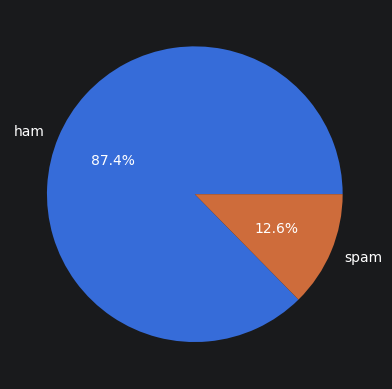

In [5]:
import matplotlib.pyplot as plt
plt.pie(k['target'].value_counts(),labels=['ham','spam'],autopct='%1.1f%%')
plt.show()

In [6]:
!pip install nltk
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')  # ← add this line

k['num_character'] = k['text'].apply(len)
k.head()

k['num_word'] = k['text'].apply(lambda x: len(nltk.word_tokenize(x)))
k.head()
k['num_sentence'] = k['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
k.head()
k[['text', 'num_character', 'num_word', 'num_sentence']].describe()



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kshit\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\kshit\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,num_character,num_word,num_sentence
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [7]:
import pandas as pd
import nltk
import string

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
nltk.download('punkt')
nltk.download('stopwords')
try:
    nltk.download('punkt_tab')
except:
    pass

ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def transform_text(text):

    text = text.lower()


    text = nltk.word_tokenize(text)


    text = [word for word in text if word.isalnum()]

    text = [word for word in text if word not in stop_words]


    text = [ps.stem(word) for word in text]

    return " ".join(text)
k['transformed_text'] = k['text'].apply(transform_text)
k.head()



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kshit\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kshit\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\kshit\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,target,text,num_character,num_word,num_sentence,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


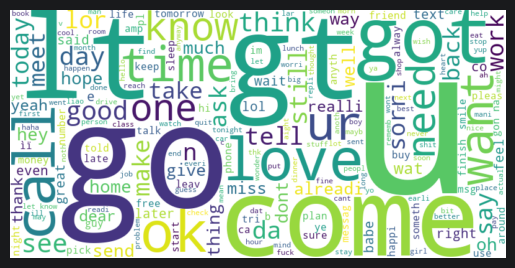

In [8]:
!pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(
    width=800,
    height=400,
    min_font_size=10,
    background_color='white'
)

spam_wc = wc.generate(k[k['target'] == 0]['transformed_text'].str.cat(sep=" "))

plt.imshow(spam_wc, interpolation='bilinear')
plt.axis('off')
plt.show()

In [9]:
k.head()

,target,text,num_character,num_word,num_sentence,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [10]:
spam_corpus=[]
for msg in k[k['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)
len(spam_corpus)

9939


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


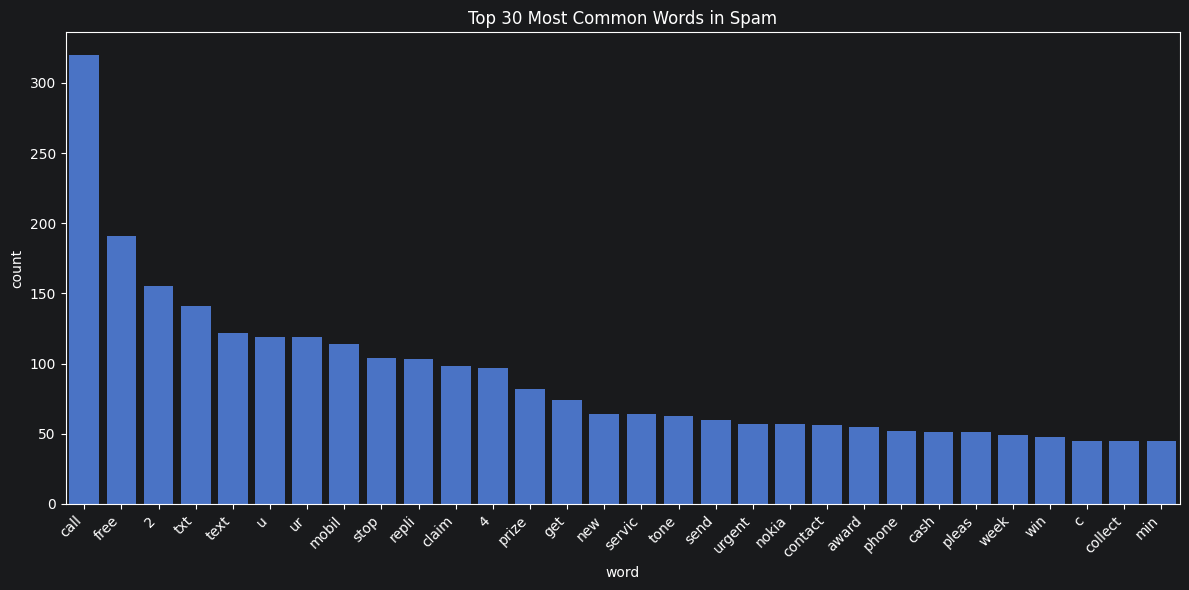

In [11]:
!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

# Create dataframe once (not twice)
top_words = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word', 'count'])

# Correct modern syntax
plt.figure(figsize=(12, 6))
sns.barplot(data=top_words, x='word', y='count')
plt.xticks(rotation=45, ha='right')
plt.title('Top 30 Most Common Words in Spam')
plt.tight_layout()
plt.show()


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


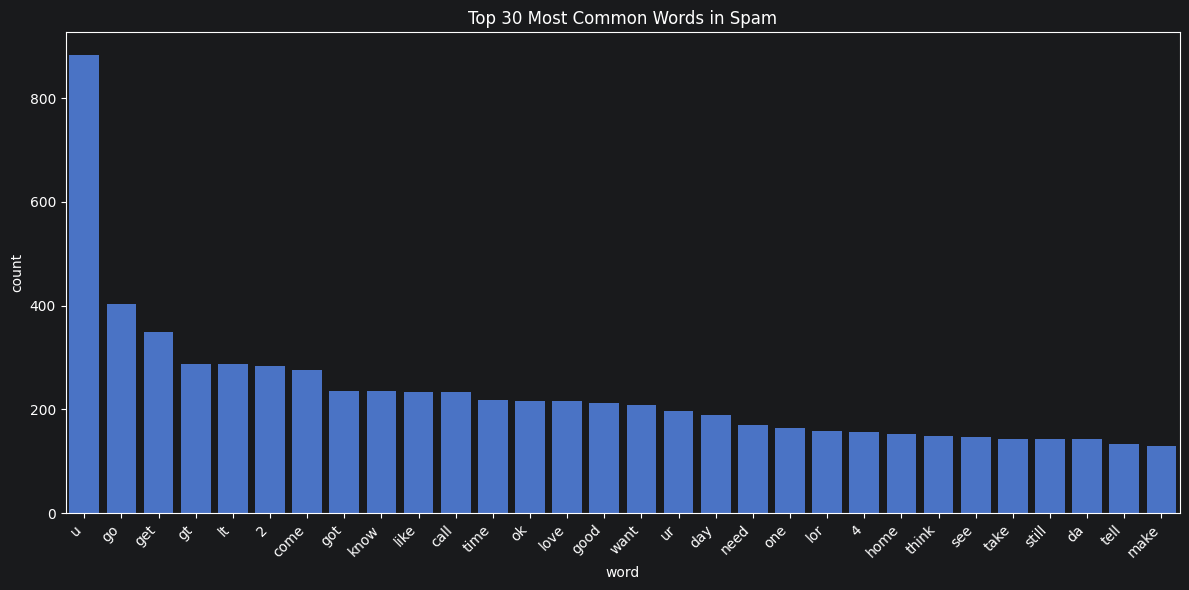

In [12]:
ham_corpus=[]
for msg in k[k['target']==0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)
len(ham_corpus)
!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

# Create dataframe once (not twice)
top_words = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['word', 'count'])

# Correct modern syntax
plt.figure(figsize=(12, 6))
sns.barplot(data=top_words, x='word', y='count')
plt.xticks(rotation=45, ha='right')
plt.title('Top 30 Most Common Words in Spam')
plt.tight_layout()
plt.show()

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(max_features=3000)
X=tfidf.fit_transform(k['transformed_text']).toarray()
X.shape
y=k['target'].values
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score
mnb=MultinomialNB()
mnb.fit(X_train,y_train)
y_pred2=mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9671179883945842
[[885   0]
 [ 34 115]]
1.0


In [14]:
from sklearn.ensemble import VotingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score

# These 3 are all fast on text data
estimators = [
    ('mnb', MultinomialNB()),
    ('dt', DecisionTreeClassifier()),
    ('lr', LogisticRegression())
]

model = VotingClassifier(estimators=estimators, voting='soft')
model.fit(X_train, y_train)

y_pred_vote = model.predict(X_test)
print("Accuracy  :", accuracy_score(y_test, y_pred_vote))
print("Precision :", precision_score(y_test, y_pred_vote))

# Save
import pickle
with open("spam_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("Saved!")

Accuracy  : 0.97678916827853
Precision : 0.9921259842519685
Saved!


In [16]:
import pickle
import os

# This will print where files are being saved
print(os.getcwd())

with open("spam_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("Saved at:", os.getcwd())

C:\Users\kshit\PyCharmMiscProject
Saved at: C:\Users\kshit\PyCharmMiscProject
